In [3]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [9]:
df['date_added'] = df['date_added'].fillna('Unknown')

In [10]:
df.drop(columns=['director', 'cast'], inplace=True)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.isnull().sum()
df.shape

(8807, 10)

In [14]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

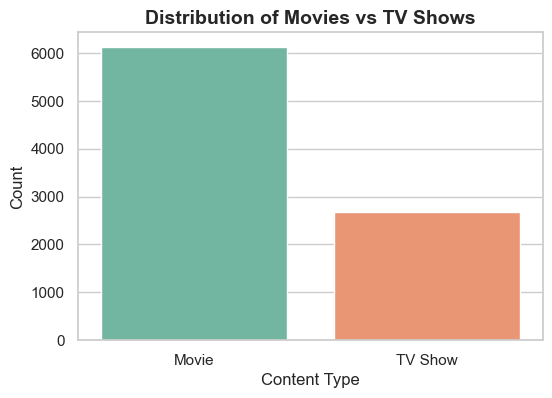

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)

plt.title("Distribution of Movies vs TV Shows", fontsize=14, fontweight='bold')
plt.savefig("images/movies_vs_tvshows.png", dpi=300, bbox_inches='tight')
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

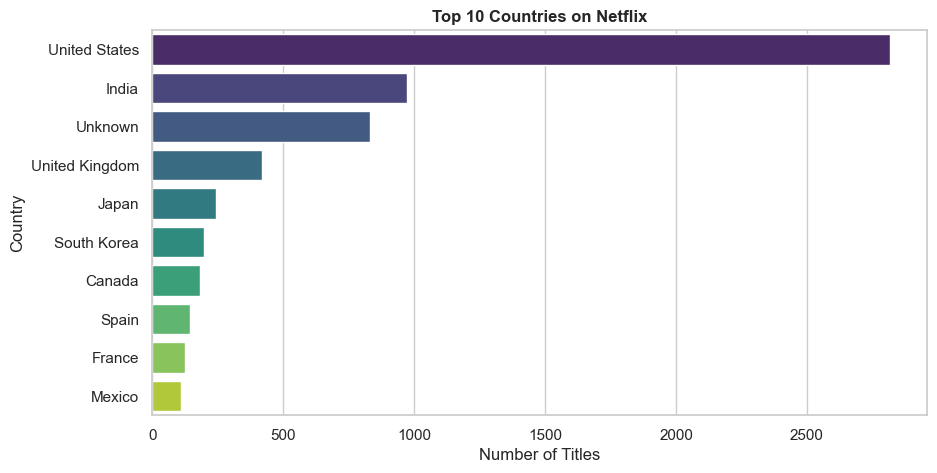

In [42]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,   # FIX for future warning
    palette='viridis',
    legend=False
)

plt.title("Top 10 Countries on Netflix", fontweight='bold')
plt.savefig("images/top_countries.png", dpi=300, bbox_inches='tight')
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

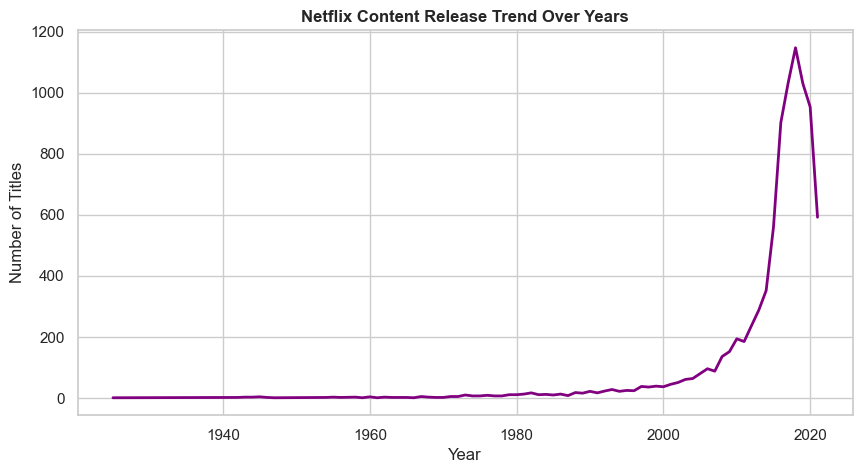

In [43]:
year_trend = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=year_trend.index,
    y=year_trend.values,
    color='purple',
    linewidth=2
)

plt.title("Netflix Content Release Trend Over Years", fontweight='bold')
plt.savefig("images/netflix_trend_over_years.png", dpi=300, bbox_inches='tight')
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

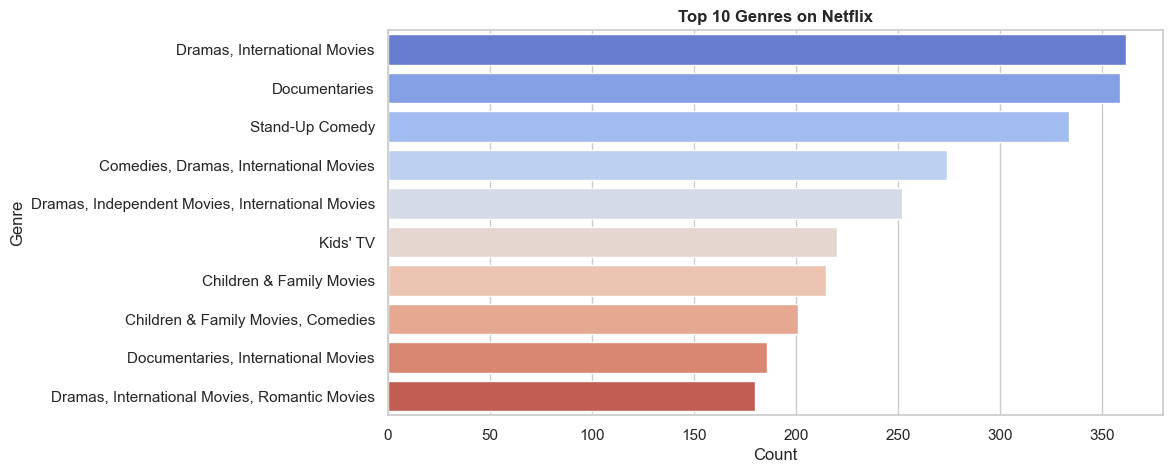

In [44]:
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette='coolwarm',
    legend=False
)

plt.title("Top 10 Genres on Netflix", fontweight='bold')
plt.savefig("images/top_genres.png", dpi=300, bbox_inches='tight')
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

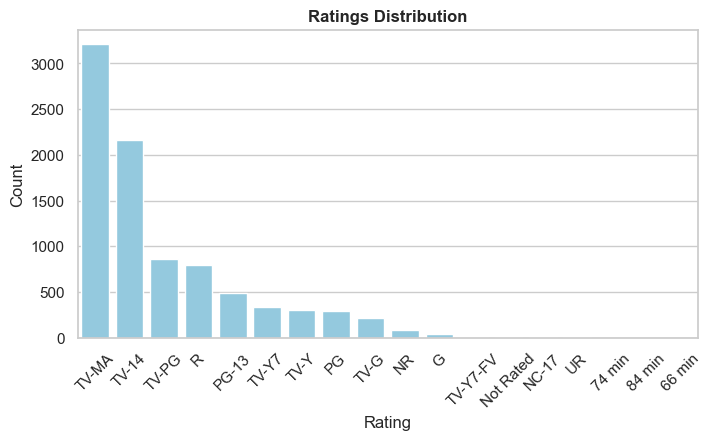

In [41]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().index,
    color="skyblue"   # no palette → no warning
)

plt.title("Ratings Distribution", fontweight='bold')
plt.savefig("images/rating_distribution.png", dpi=300, bbox_inches='tight')
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

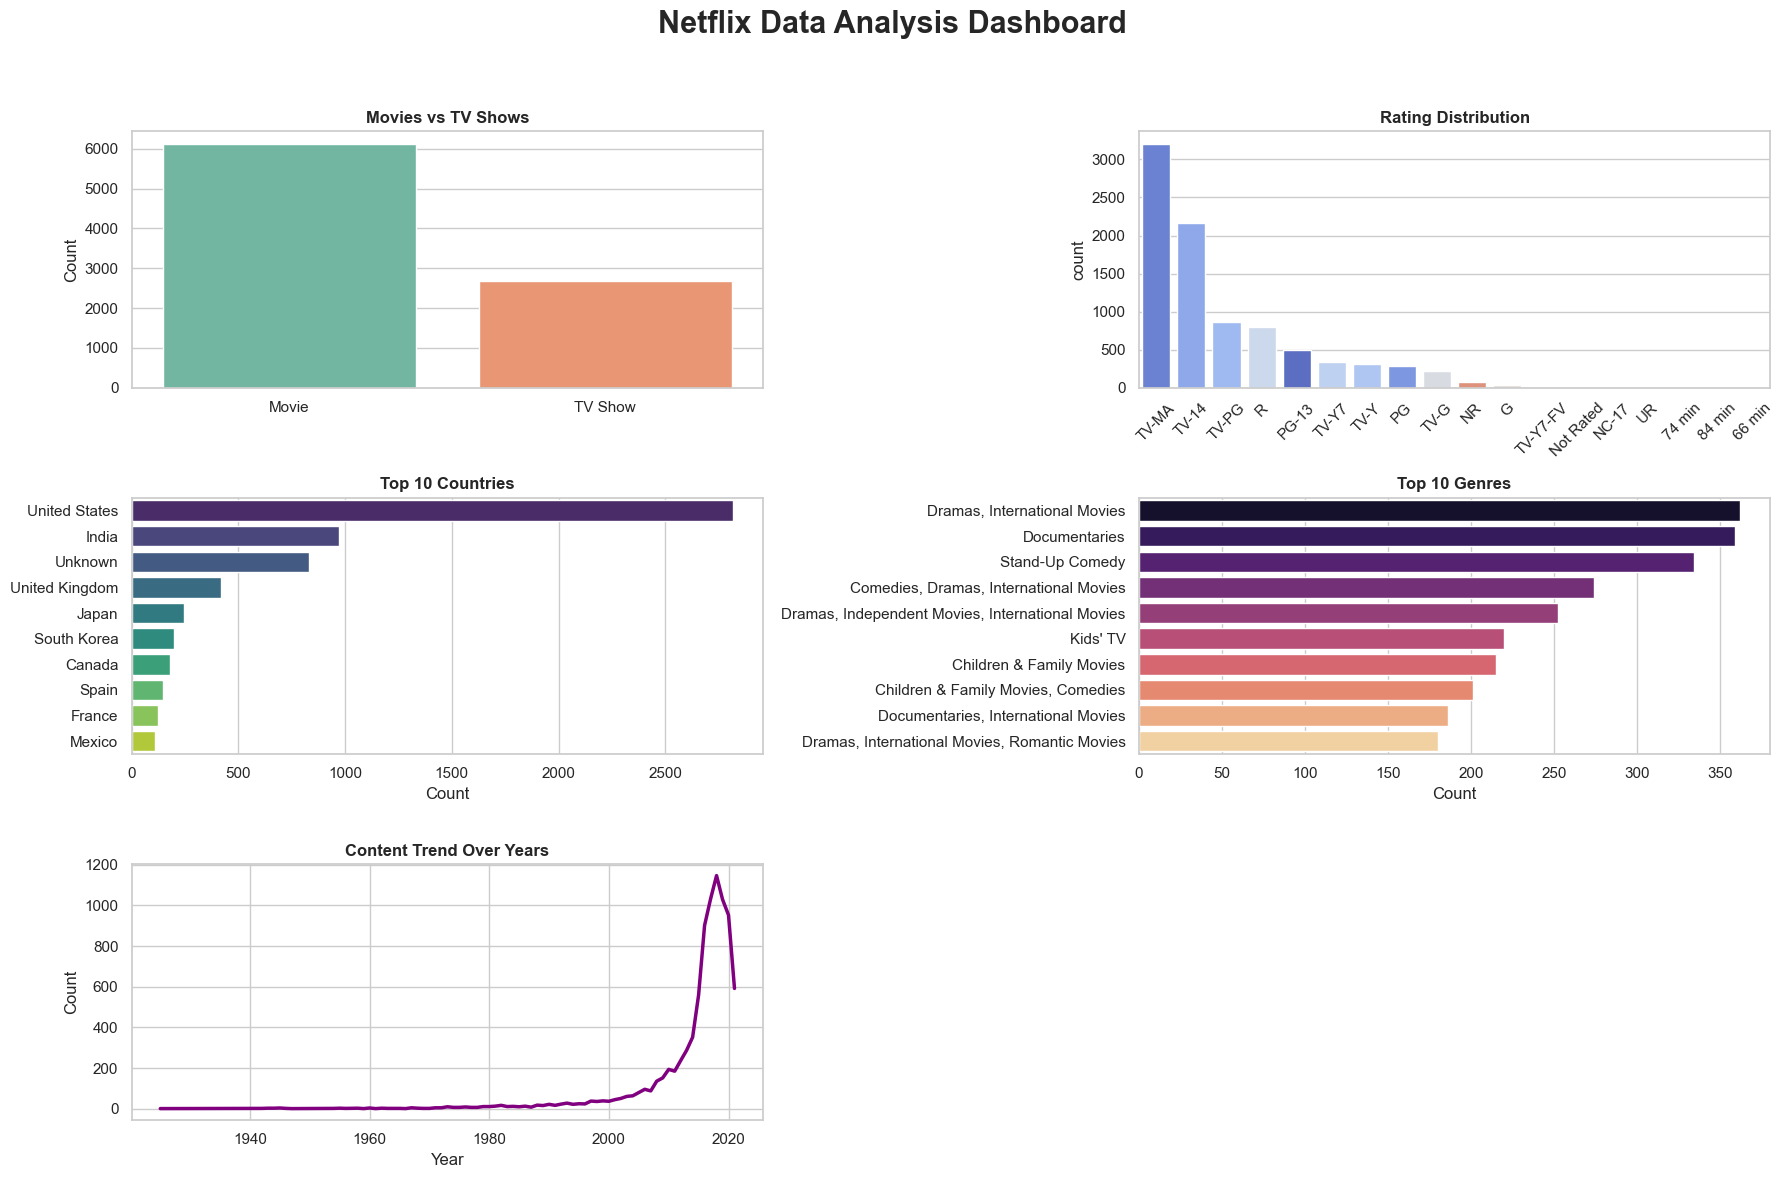

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# -----------------------------
# MAIN FIGURE + TITLE
# -----------------------------
fig = plt.figure(figsize=(18,12))
fig.suptitle("Netflix Data Analysis Dashboard", fontsize=22, fontweight='bold', y=0.98)

# -----------------------------
# 1. Movies vs TV Shows
# -----------------------------
ax1 = plt.subplot(3, 2, 1)

sns.countplot(
    data=df,
    x='type',
    hue='type',
    palette='Set2',
    legend=False,
    ax=ax1
)

ax1.set_title("Movies vs TV Shows", fontweight='bold')
ax1.set_xlabel("")
ax1.set_ylabel("Count")

# -----------------------------
# 2. Rating Distribution
# -----------------------------
ax2 = plt.subplot(3, 2, 2)

sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().index,
    hue='rating',
    palette='coolwarm',
    legend=False,
    ax=ax2
)

ax2.set_title("Rating Distribution", fontweight='bold')
ax2.set_xlabel("")
ax2.tick_params(axis='x', rotation=45)

# -----------------------------
# 3. Top 10 Countries
# -----------------------------
ax3 = plt.subplot(3, 2, 3)

country_counts = df['country'].value_counts().head(10)

sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    hue=country_counts.index,
    palette='viridis',
    legend=False,
    ax=ax3
)

ax3.set_title("Top 10 Countries", fontweight='bold')
ax3.set_xlabel("Count")
ax3.set_ylabel("")

# -----------------------------
# 4. Top 10 Genres
# -----------------------------
ax4 = plt.subplot(3, 2, 4)

genre_counts = df['listed_in'].value_counts().head(10)

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    hue=genre_counts.index,
    palette='magma',
    legend=False,
    ax=ax4
)

ax4.set_title("Top 10 Genres", fontweight='bold')
ax4.set_xlabel("Count")
ax4.set_ylabel("")

# -----------------------------
# 5. Content Trend Over Years
# -----------------------------
ax5 = plt.subplot(3, 2, 5)

year_counts = df['release_year'].value_counts().sort_index()

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    color="purple",
    linewidth=2.5,
    ax=ax5
)

ax5.set_title("Content Trend Over Years", fontweight='bold')
ax5.set_xlabel("Year")
ax5.set_ylabel("Count")

# -----------------------------
# REMOVE EMPTY SPACE (6th subplot)
# -----------------------------
fig.delaxes(plt.subplot(3, 2, 6))

# -----------------------------
# FINAL LAYOUT ADJUSTMENT
# -----------------------------
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("images/netflix_dashboard.png", dpi=300, bbox_inches='tight')

plt.show()

In [39]:
df.to_csv("cleaned_netflix.csv", index=False)